# California 300-m/1-km ecological error-diagnostic case study

## tl;dr

- Local KelpWatch canopy was rebuilt around Giraldo field sites at two prespecified supports rather than assigning the field data to coastwide 5-km cells.
- Field-matched coverage was 300 m: 152 sites, 752 site-years; 1000 m: 169 sites, 965 site-years.
- Logistic MUR-minus-trajectory increments were 300 m -0.011 (95% CI -0.053 to +0.035); 1000 m +0.011 (95% CI -0.031 to +0.055).
- 0 ecological axis–error associations passed the strict cross-model and cross-support stability rule.
- The result is a California partial-sample diagnostic of when the remote-data model fails; it is not a coastwide causal model and not a claim that 300 m is the true ecological process scale.

## Context & Methods

The coastwide ranking model and the ecological explanation are separated because they answer different questions and operate at different spatial supports. Around each Giraldo site, pre-2005 positive KelpWatch pixels define a fixed footprint. Annual canopy requires at least three valid quarters including Q3 and at least 50% valid habitat pixels. Overlapping footprints are grouped before inference.

Daily NASA JPL MUR v4.1 SST is obtained from public ERDDAP replicas at 0.01° support, with a cross-endpoint value-parity gate. Features include annual mean and maximum SST, maximum 7-day anomaly, positive anomaly degree-days, days above an expanding 90th percentile, and maximum consecutive hot days. Climatologies use strictly prior days.

Complete MUR thermal features begin in 2004. Forecast evaluation begins in 2008 so every first fold has four complete training years; evaluation ends in 2021 with the field dataset.

### Key assumptions

- Giraldo sites are a non-probability California field sample (189 sites with coordinates before local-support quality filters).
- MUR is surface SST and may differ from benthic temperature experienced by kelp and grazers.
- Field ecological axes describe associations with prediction errors, not identified causal effects.
- The field observation year is aligned to the forecast-year diagnostic; uneven survey timing and missing site-years constrain power.
- Multiple testing is controlled within each support, model family, and diagnostic outcome, followed by a stricter cross-support stability rule.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'outputs').exists() and (ROOT.parent / 'outputs').exists():
    ROOT = ROOT.parent
RUN = ROOT / 'outputs/experiments/20260816_california_local_ecology_v2'
assert (RUN / 'manifest.json').exists()

coverage = pd.read_csv(RUN / 'support_coverage.csv')
mur_quality = pd.read_csv(RUN / 'mur_quality_checks.csv')
mur_endpoint_parity = pd.read_csv(RUN / 'mur_endpoint_parity_checks.csv')
performance = pd.read_csv(RUN / 'performance_summary.csv')
increments = pd.read_csv(RUN / 'increment_summary.csv')
ecology_coverage = pd.read_csv(RUN / 'ecology_coverage.csv')
associations = pd.read_csv(RUN / 'ecological_axis_associations.csv')
stability = pd.read_csv(RUN / 'condition_stability_summary.csv')
leave_cluster = pd.read_csv(RUN / 'leave_overlap_cluster_out_summary.csv')
validation = pd.read_csv(RUN / 'validation_recheck.csv')
assert validation['passed'].all()
print('Loaded', RUN.relative_to(ROOT))
print('Validation:', int(validation['passed'].sum()), '/', len(validation))

Loaded outputs/experiments/20260816_california_local_ecology_v2
Validation: 26 / 26


## Data

In [2]:
coverage

,support_m,stable_sites,overlap_clusters,eligible_forecast_rows,forecast_events,field_matched_rows,field_matched_sites,field_matched_events
0,300,168,130,2018,865,964,153,413
1,1000,182,77,2527,990,1229,171,477


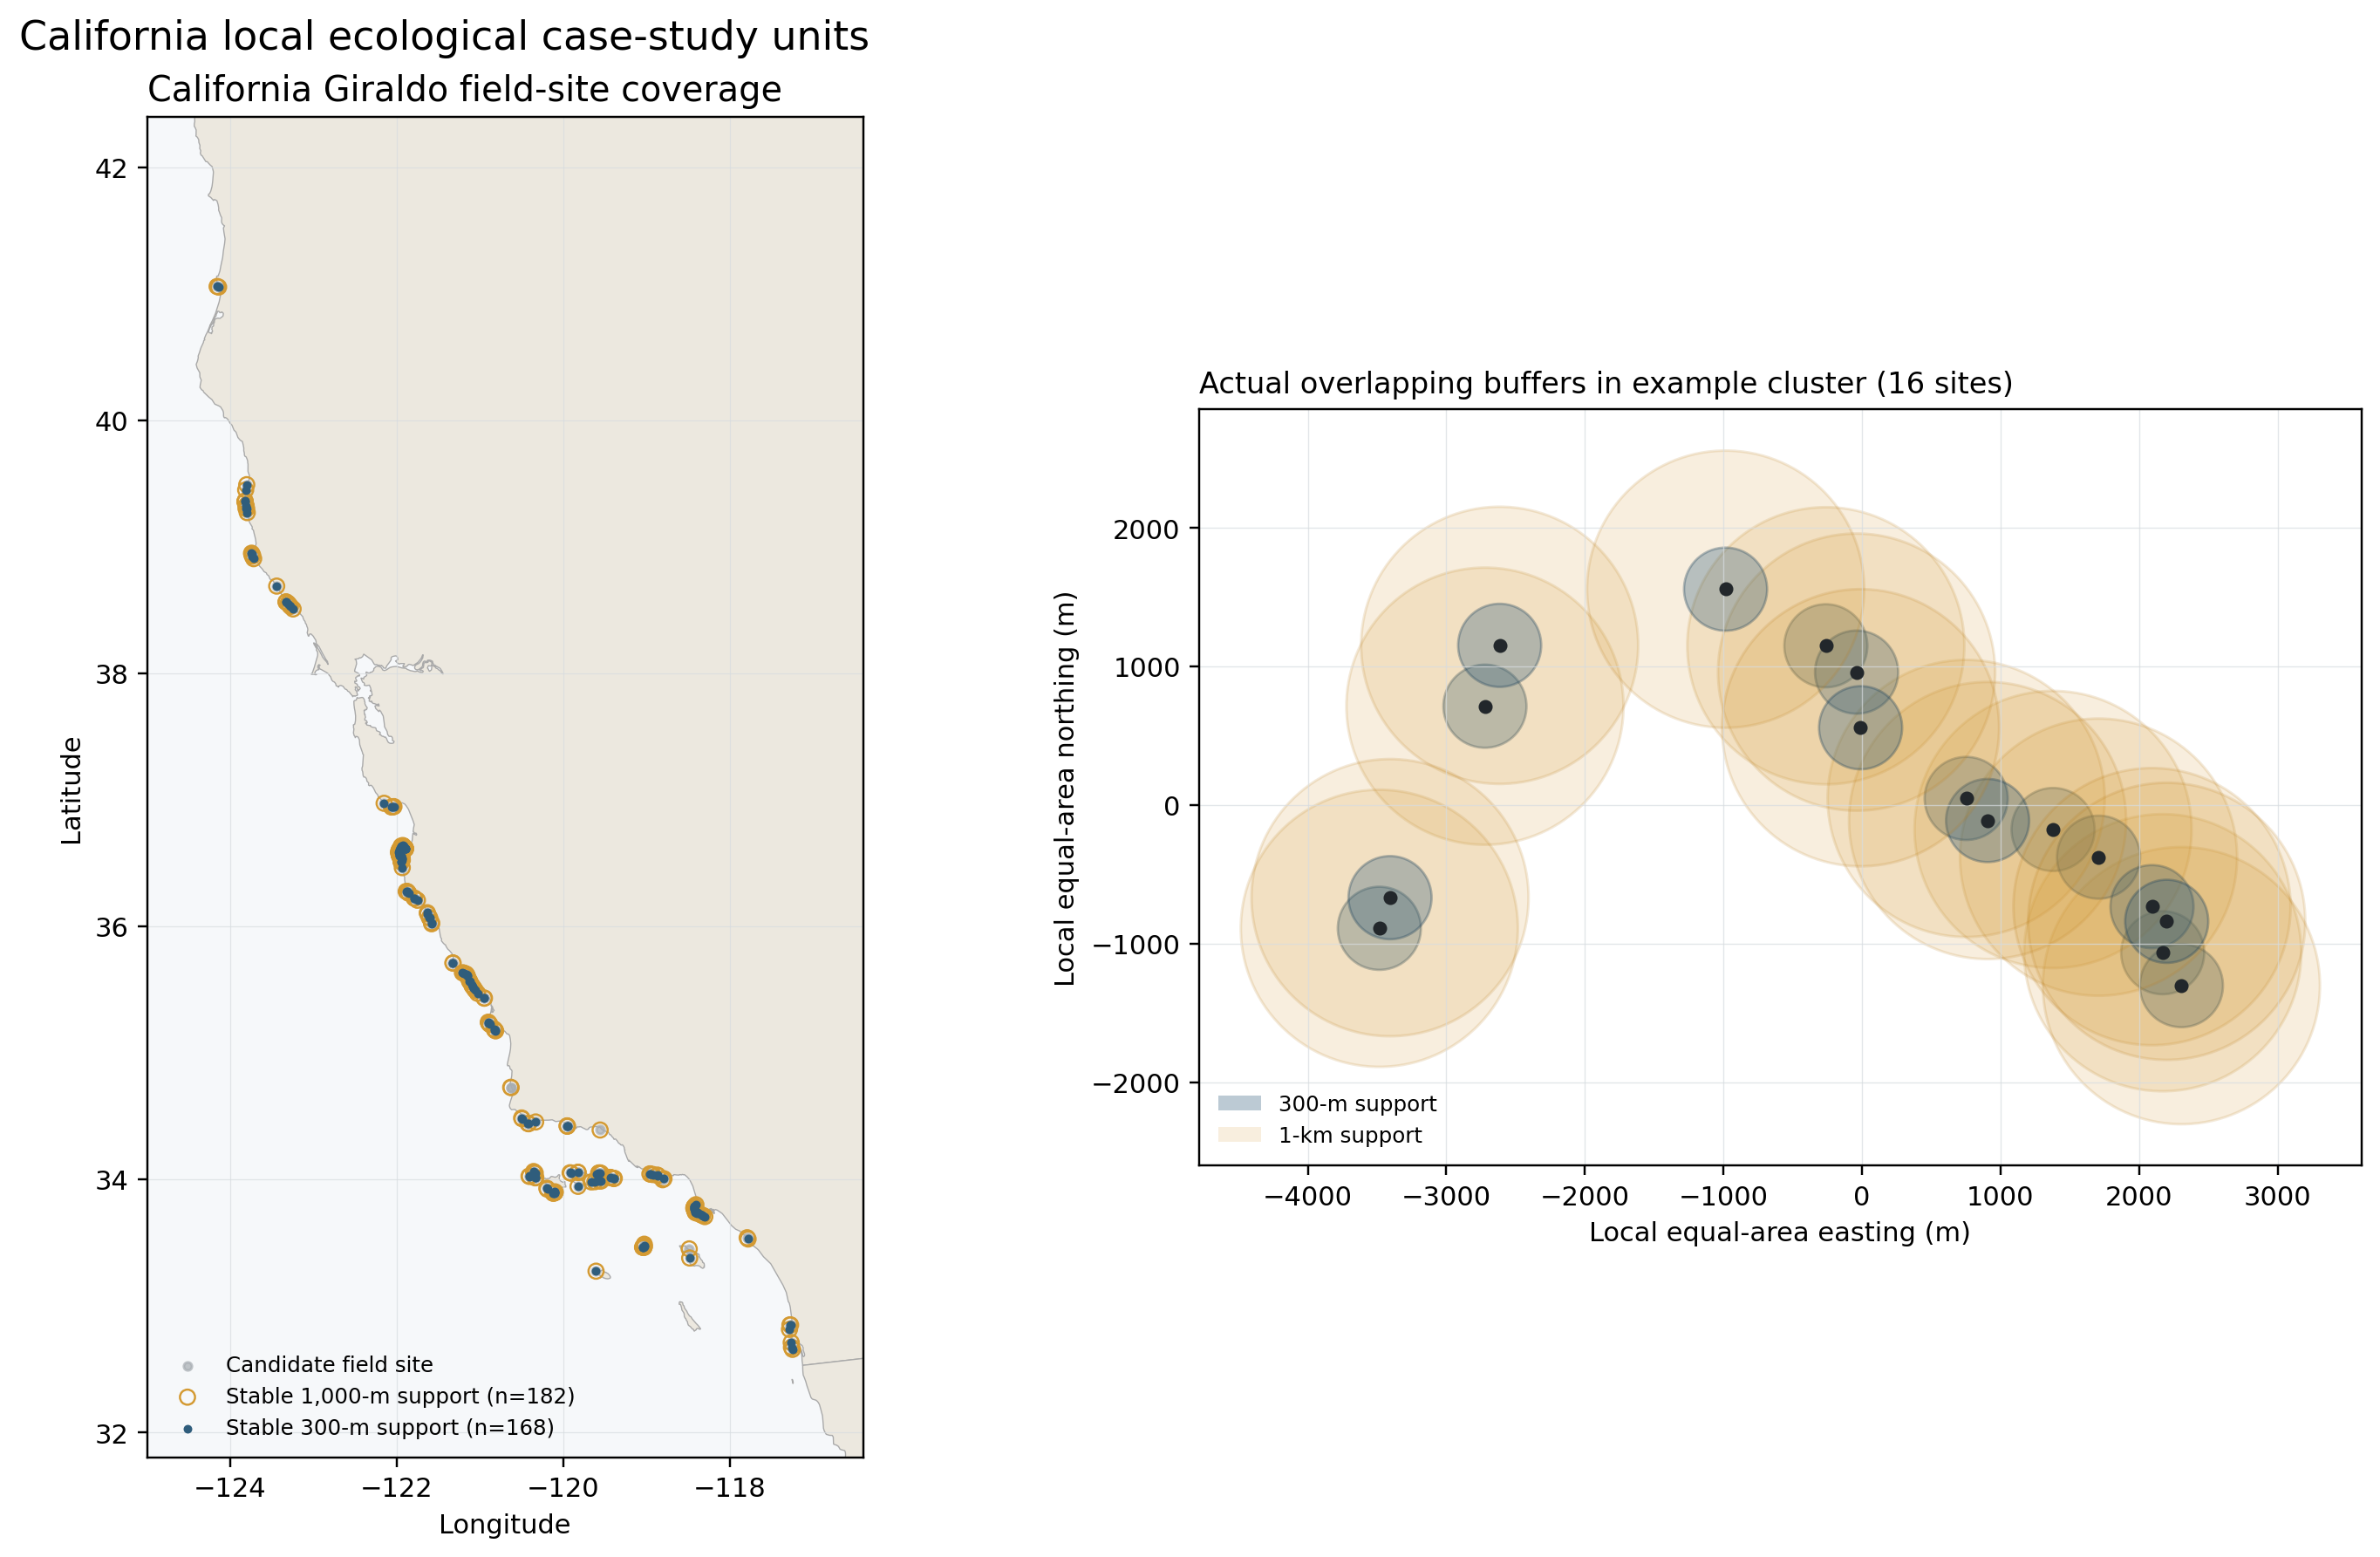

In [3]:
display(Image(filename=str(RUN / 'figure_00_california_sites_supports.png')))

In [4]:
mur_quality

,check,value,passed
0,mapping_site_keys_unique,0.000000,True
1,maximum_mapping_distance_le_10km,0.924496,True
2,feature_keys_unique,0.000000,True
3,erddap_endpoint_parity,0.000000,True
4,forecast_feature_completeness_ge_95pct,1.000000,True
5,strictly_past_climatology,1.000000,True


In [5]:
mur_endpoint_parity

,endpoint,rows,max_absolute_difference_celsius_vs_noaa,passed
0,https://coastwatch.pfeg.noaa.gov/erddap/gridda...,3,0.0,True
1,https://erddap.riddc.brown.edu/erddap/griddap/...,3,0.0,True
2,https://erddap.marine.usf.edu/erddap/griddap/j...,3,0.0,True


In [6]:
ecology_coverage

,support_m,matched_rows,matched_sites,overlap_clusters,years,events
0,300,752,152,120,14,337
1,1000,965,169,73,14,401


The prediction panel can be much larger than the field-matched panel. Ecological claims therefore use only matched site-years and report both site and overlap-cluster counts.

## Results

### 1. Local-support predictive increments

In [7]:
increments[['support_m', 'model_family', 'comparison', 'estimate', 'ci_low', 'ci_high', 'paired_years']].round(4)

,support_m,model_family,comparison,estimate,ci_low,ci_high,paired_years
0,300,logistic,trajectory_minus_current,0.0713,0.0351,0.1138,14
1,300,logistic,mur_minus_trajectory,-0.0107,-0.0526,0.0348,14
2,300,random_forest,trajectory_minus_current,0.0411,-0.0056,0.0832,14
3,300,random_forest,mur_minus_trajectory,0.0275,-0.0092,0.0694,14
4,300,xgboost,trajectory_minus_current,0.0190,-0.0272,0.0591,14
5,300,xgboost,mur_minus_trajectory,0.0466,0.0151,0.0796,14
6,1000,logistic,trajectory_minus_current,0.0262,0.0003,0.0518,14
7,1000,logistic,mur_minus_trajectory,0.0107,-0.0305,0.0549,14
8,1000,random_forest,trajectory_minus_current,0.0263,-0.0033,0.0595,14
9,1000,random_forest,mur_minus_trajectory,0.0190,-0.0015,0.0406,14


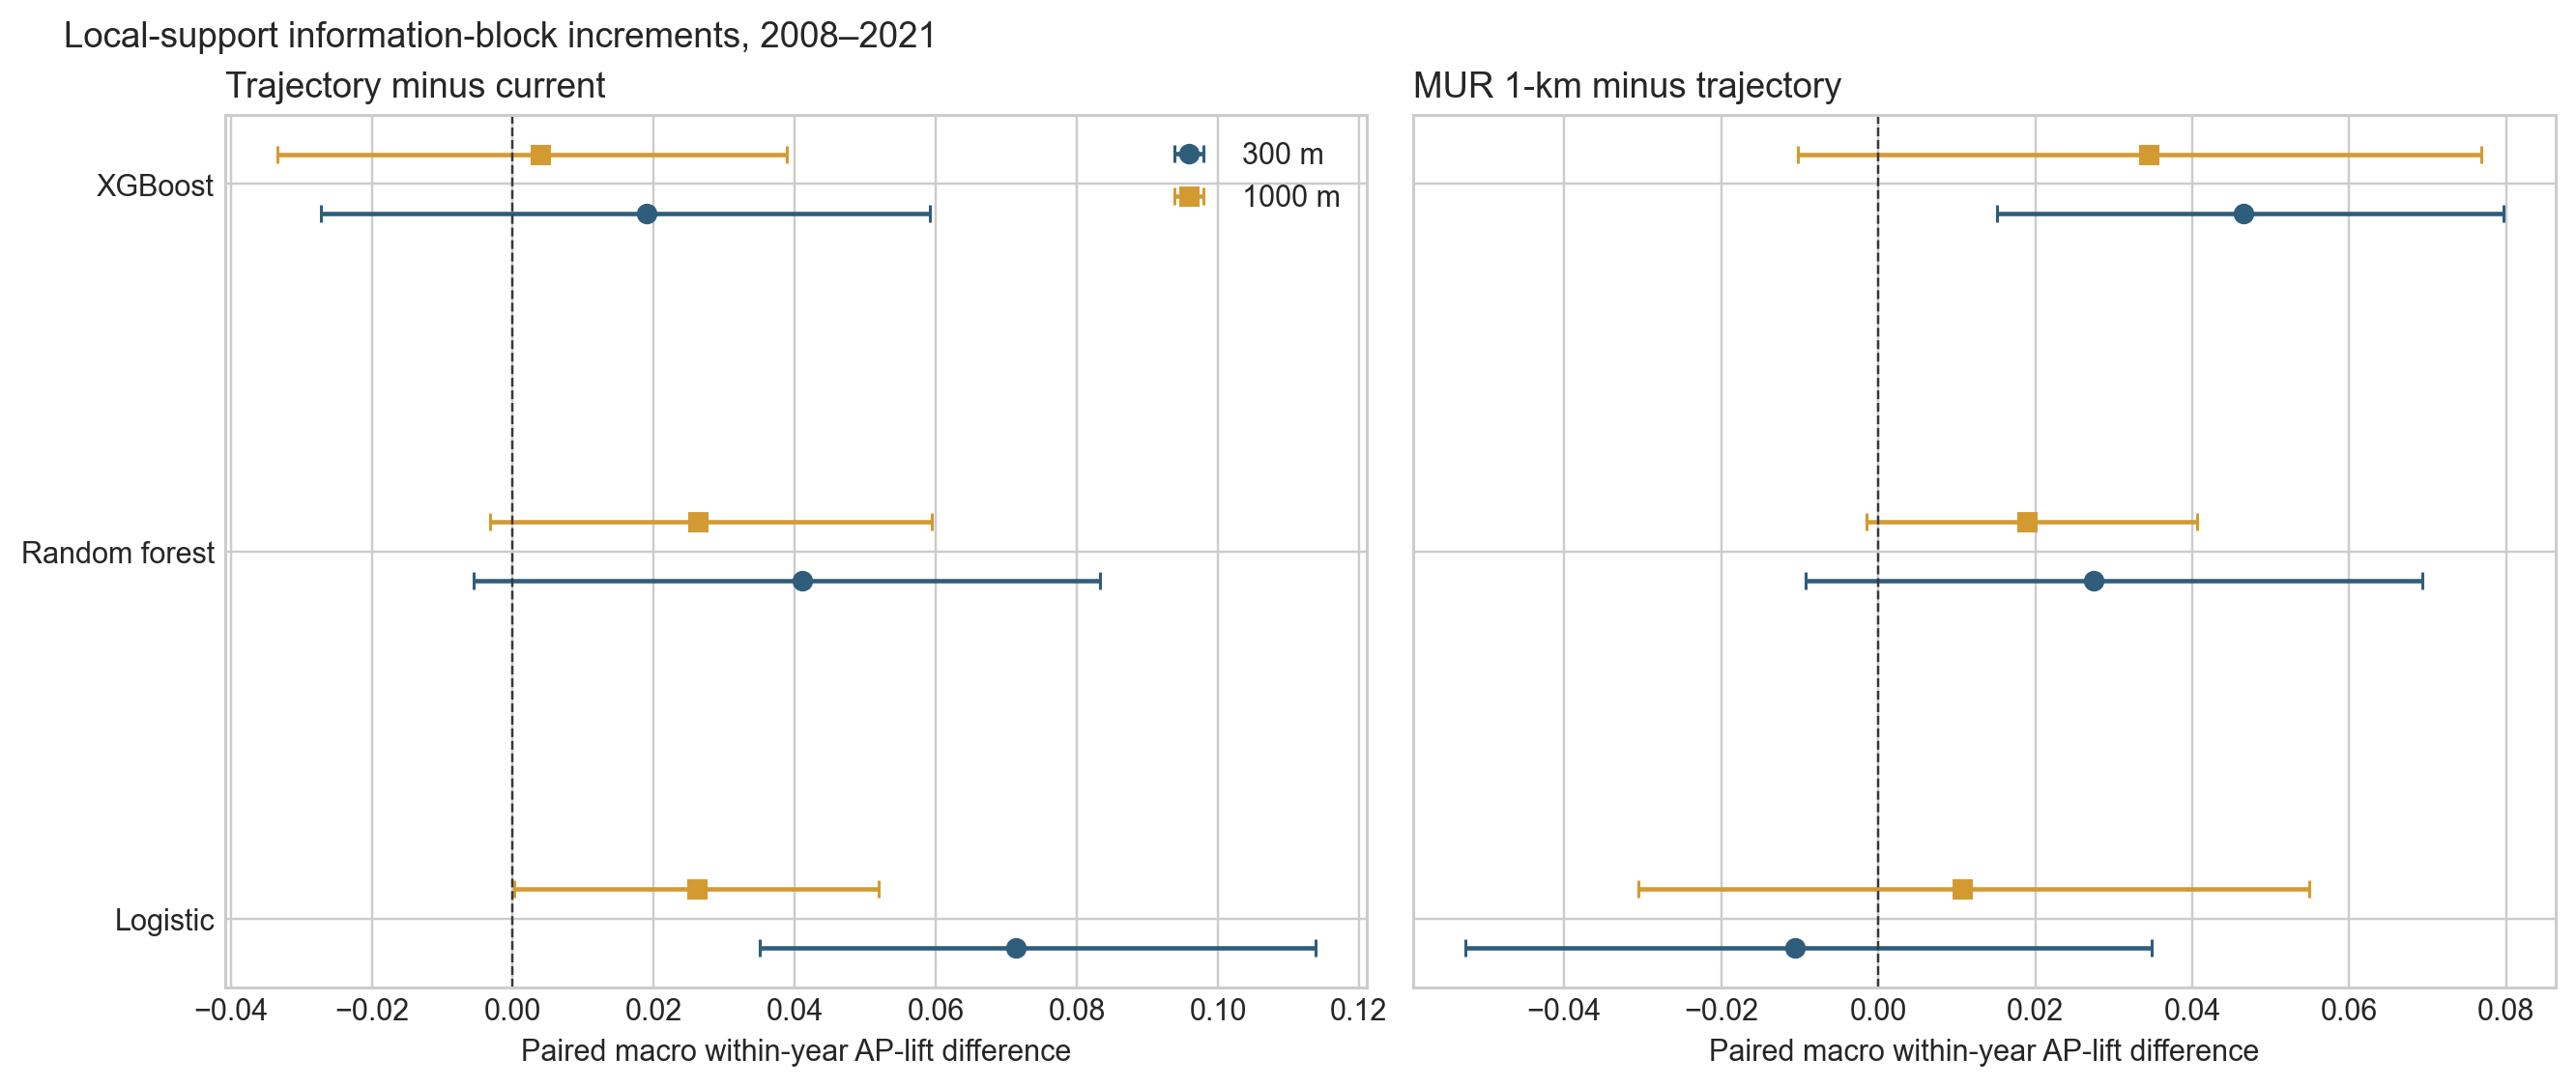

In [8]:
display(Image(filename=str(RUN / 'figure_01_local_support_increments.png')))

### 2. Ecological associations with prediction errors

In [9]:
stability.sort_values(['stable_condition_supported', 'outcome', 'axis'], ascending=[False, True, True]).round(4)

,outcome,axis,primary_300m_estimate,primary_300m_ci_low,primary_300m_ci_high,primary_300m_q_value,same_direction_family_count_300m,estimate_1000m_logistic,support_direction_consistent,stable_condition_supported
18,mur_brier_gain,depth_m,0.0029,-0.0067,0.0125,0.5191,2,-0.0031,False,False
16,mur_brier_gain,grazing_log1p,-0.0053,-0.0212,0.0106,0.5191,3,-0.0053,True,False
19,mur_brier_gain,kelp_species_contrast,-0.0062,-0.0250,0.0125,0.5191,3,-0.0018,True,False
17,mur_brier_gain,rock_probability,-0.0096,-0.0218,0.0025,0.4396,1,-0.0096,True,False
14,mur_signed_rank_gain_pp,depth_m,0.0659,-1.2304,1.3622,0.9281,1,0.3554,True,False
12,mur_signed_rank_gain_pp,grazing_log1p,-0.0929,-2.2758,2.0899,0.9281,3,-2.0554,True,False
15,mur_signed_rank_gain_pp,kelp_species_contrast,-2.6017,-5.5646,0.3611,0.3210,3,-3.5377,True,False
13,mur_signed_rank_gain_pp,rock_probability,-0.9200,-2.3338,0.4937,0.3664,1,-2.2095,True,False
6,trajectory_false_negative,depth_m,0.0396,-0.0207,0.0998,0.3590,3,0.0170,True,False
4,trajectory_false_negative,grazing_log1p,0.0533,-0.0206,0.1271,0.3590,3,0.1064,True,False


In [10]:
leave_cluster.sort_values(['same_direction_fraction', 'maximum_absolute_change']).round(4)

,outcome,axis,reference_estimate_per_sd,clusters_left_out,minimum_estimate,maximum_estimate,maximum_absolute_change,same_direction_fraction
4,mur_signed_rank_gain_pp,depth_m,0.0659,120,-0.2957,0.3566,0.3616,0.8833
5,mur_signed_rank_gain_pp,grazing_log1p,-0.0929,120,-0.4161,0.3042,0.3971,0.9167
14,trajectory_false_positive,kelp_species_contrast,0.0050,96,-0.0072,0.0172,0.0123,0.9583
17,trajectory_rank_quality_pp,grazing_log1p,-0.3474,120,-1.1574,0.2356,0.8100,0.9917
0,mur_brier_gain,depth_m,0.0029,120,0.0012,0.0046,0.0018,1.0000
1,mur_brier_gain,grazing_log1p,-0.0053,120,-0.0079,-0.0035,0.0026,1.0000
3,mur_brier_gain,rock_probability,-0.0096,120,-0.0124,-0.0086,0.0028,1.0000
2,mur_brier_gain,kelp_species_contrast,-0.0062,120,-0.0102,-0.0040,0.0039,1.0000
12,trajectory_false_positive,depth_m,-0.0076,96,-0.0145,-0.0028,0.0069,1.0000
9,trajectory_false_negative,grazing_log1p,0.0533,96,0.0436,0.0603,0.0096,1.0000


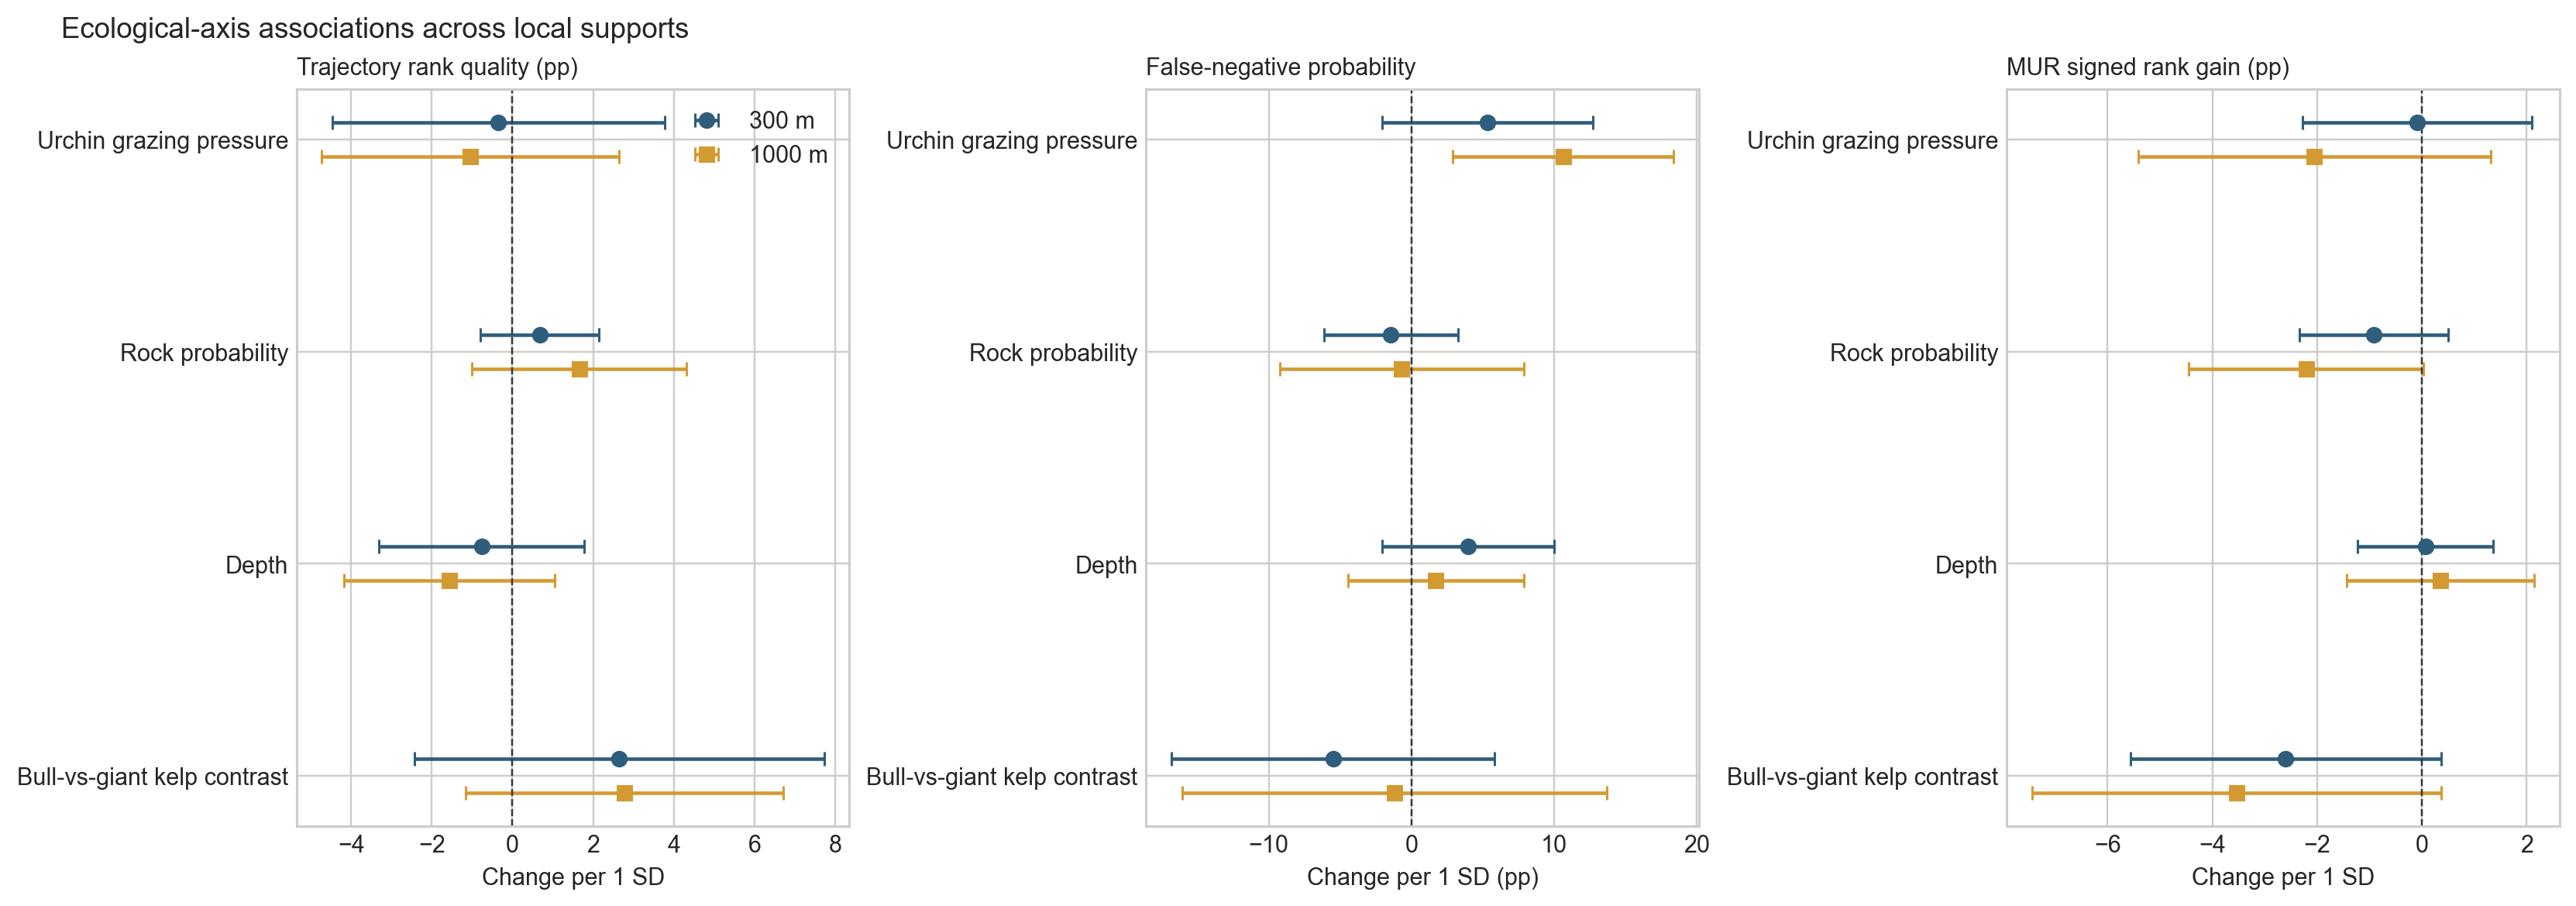

In [11]:
display(Image(filename=str(RUN / 'figure_02_ecological_associations_by_support.png')))

A condition is highlighted only when the 300-m Logistic association passes BH control, at least two 300-m model families agree in direction, and the 1-km Logistic estimate has the same direction. This guards against selecting a favorable support after seeing results.

### 3. Full performance context

In [12]:
performance.round(4)

,support_m,model_family,feature_set,estimable_years,macro_within_year_ap_lift,ci_low,ci_high,micro_recall_top20
0,300,logistic,current_only,14,0.1072,0.0601,0.1634,0.2497
1,300,logistic,current_plus_trajectory,14,0.1785,0.1261,0.2345,0.2798
2,300,logistic,trajectory_plus_mur,14,0.1678,0.0977,0.2507,0.2785
3,300,random_forest,current_only,14,0.0986,0.0567,0.1500,0.2606
4,300,random_forest,current_plus_trajectory,14,0.1397,0.0871,0.1960,0.2606
5,300,random_forest,trajectory_plus_mur,14,0.1671,0.1050,0.2364,0.2826
6,300,xgboost,current_only,14,0.0895,0.0483,0.1381,0.2510
7,300,xgboost,current_plus_trajectory,14,0.1084,0.0635,0.1636,0.2565
8,300,xgboost,trajectory_plus_mur,14,0.1550,0.0975,0.2169,0.2785
9,1000,logistic,current_only,14,0.1230,0.0640,0.1867,0.2738


## Takeaways

1. This case study tests whether error patterns are systematically associated with local grazing, habitat, depth, or kelp-composition axes.
2. The two support sizes are a prespecified sensitivity analysis; concordance is more credible than either support alone.
3. MUR's incremental predictive value is evaluated separately from the ecological-axis error analysis.
4. Any supported association is hypothesis-generating because the field sites are partial, non-random, and observational.
5. Coastwide management performance should be reported from the 5-km analysis; ecological interpretation should be reported from this California case study with its own denominator and limitations.